# London Weather Forecasting

## Data Loading & Preprocessing

We have selected a London Weather Dataset that goes from 1979 to 2023. There are many columns which shows different weather variables such as, mean/max temperatures, precipitations, sun time, daily global radiation... We focused in daily mean temperatures. Therefore, we have to make some changes to adapt the dataset to our needs:
- The Date column: the format was like this "YYYYMMDD" so we need to change to the date format to ease out future work.
- The Temperatures: all temperatures were multiplied by 10 something common in this type of datasets, so we have to divide by 10.
- Empty data: in some days the mean temperature misses, so we decided to fill it with the "Forward fill" technique (It copies the temperature of the day before to complete the data).

Cargando el dataset de Londres...


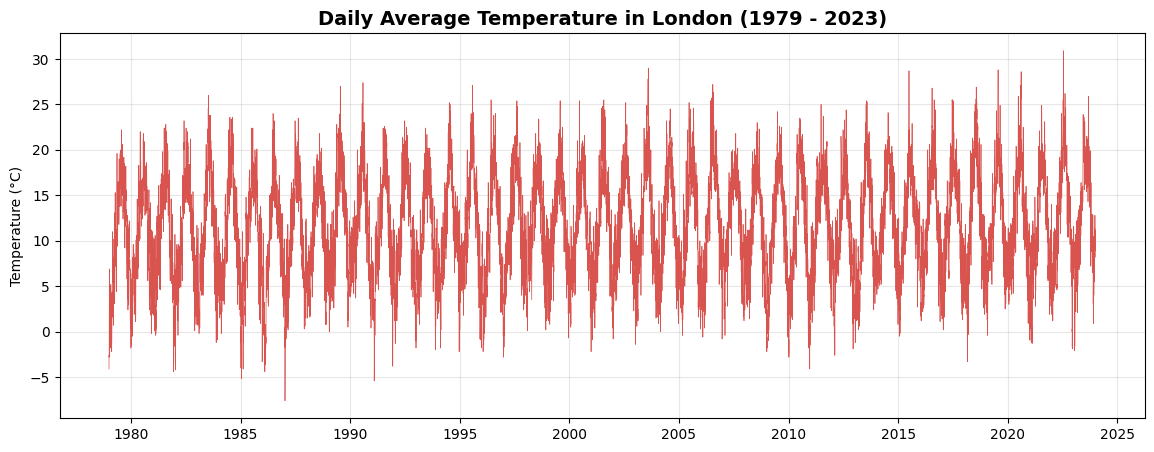

X form: torch.Size([16406, 30, 1]) ->Total days minus 30, 30 days, 1 feature
y form: torch.Size([16406, 1])


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler

# --- 1. CARGA Y LIMPIEZA DE DATOS ---
print("Cargando el dataset de Londres...")

df = pd.read_csv('london_weather_data_1979_to_2023.csv')

# Arreglamos la fecha (convertimos 19790101 a formato fecha real)
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d')
df.set_index('DATE', inplace=True)

# Vamos a predecir 'TG' (Temperatura Media / Mean Temperature)
# Dividimos entre 10 porque el dataset original no usa decimales (23.0 significa 2.3ºC)
df['TG'] = df['TG'] / 10.0

# Rellenamos los 29 días vacíos usando la temperatura del día anterior
df['TG'] = df['TG'].ffill()

# Extraemos nuestra variable objetivo
temperaturas = df['TG'].values.reshape(-1, 1)

# Visualizamos la historia climática de Londres para tu reporte
plt.figure(figsize=(14, 5))
plt.plot(df.index, temperaturas, color='#d9534f', linewidth=0.5)
plt.title('Daily Average Temperature in London (1979 - 2023)', fontweight='bold', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# --- ESCALADO DE DATOS ---
# A las redes LSTM les encantan los datos entre -1 y 1
scaler = MinMaxScaler(feature_range=(-1, 1))
temp_escaladas = scaler.fit_transform(temperaturas)

# --- CREACIÓN DE LAS VENTANAS DE TIEMPO (Sliding Windows) ---
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)] # Ej: Días del 1 al 30
        y = data[i + seq_length]     # Ej: Día 31 (el que queremos predecir)
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 30 # Miraremos los últimos 30 días para predecir el día siguiente
X, y = create_sequences(temp_escaladas, seq_length)

# Convertimos a tensores de PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

print(f"X form: {X_tensor.shape} ->Total days minus 30, 30 days, 1 feature")
print(f"y form: {y_tensor.shape}")

### Exploratory Data Analysis (EDA)

Before feeding the data into our Deep Learning models, it is crucial to understand its underlying distribution and patterns. In this section, we analyze the overall temperature distribution and visualize the monthly seasonality. The clear seasonal cycles confirm that this is a classic Time-Series problem, making Recurrent Neural Networks (like LSTM and GRU) the ideal architectures to capture these sequential patterns.

Generating exploratory data analysis (EDA) plots...


/tmp/ipykernel_3045/622322111.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='TG', data=df_eda, palette='coolwarm', ax=axes[1])


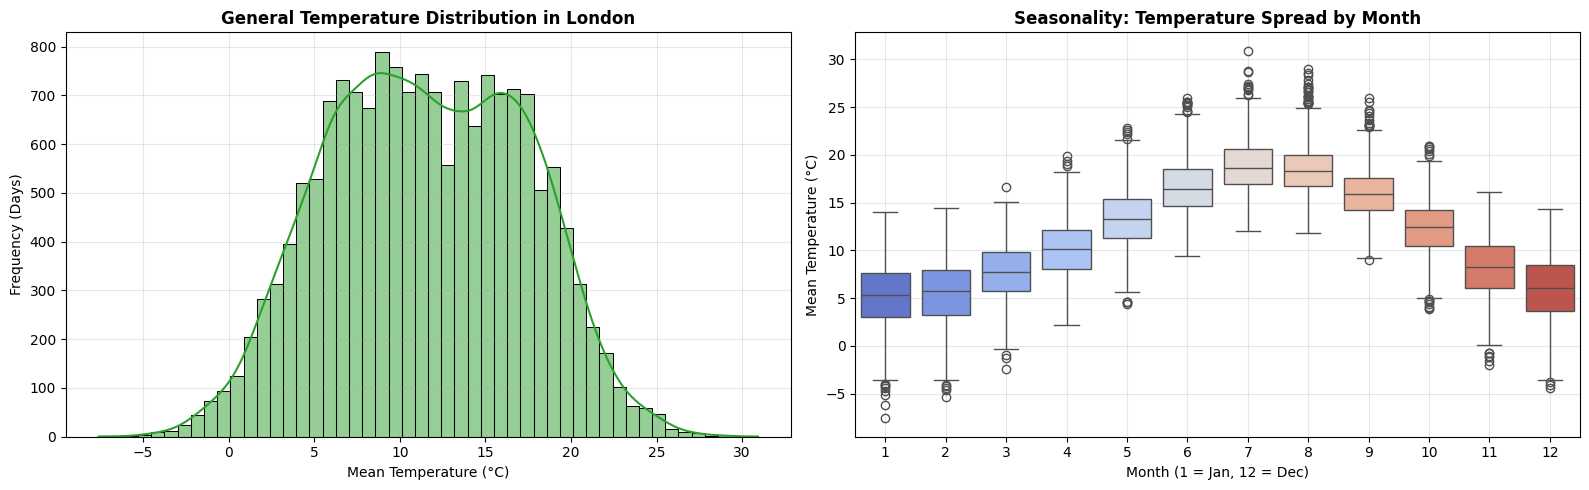

In [75]:
import seaborn as sns

# --- Advanced Exploratory Data Analysis (EDA) ---
print("Generating exploratory data analysis (EDA) plots...")

# Creamos una figura con 2 subgráficos (uno al lado del otro)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Histograma de distribución general
sns.histplot(df['TG'], bins=50, kde=True, color='#2ca02c', ax=axes[0])
axes[0].set_title('General Temperature Distribution in London', fontweight='bold')
axes[0].set_xlabel('Mean Temperature (°C)')
axes[0].set_ylabel('Frequency (Days)')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Boxplot por meses para ver la estacionalidad
# Creamos una columna temporal de 'Mes' solo para este gráfico
df_eda = df.copy()
df_eda['Month'] = df_eda.index.month

sns.boxplot(x='Month', y='TG', data=df_eda, palette='coolwarm', ax=axes[1])
axes[1].set_title('Seasonality: Temperature Spread by Month', fontweight='bold')
axes[1].set_xlabel('Month (1 = Jan, 12 = Dec)')
axes[1].set_ylabel('Mean Temperature (°C)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Long-Term Trend and Autocorrelation

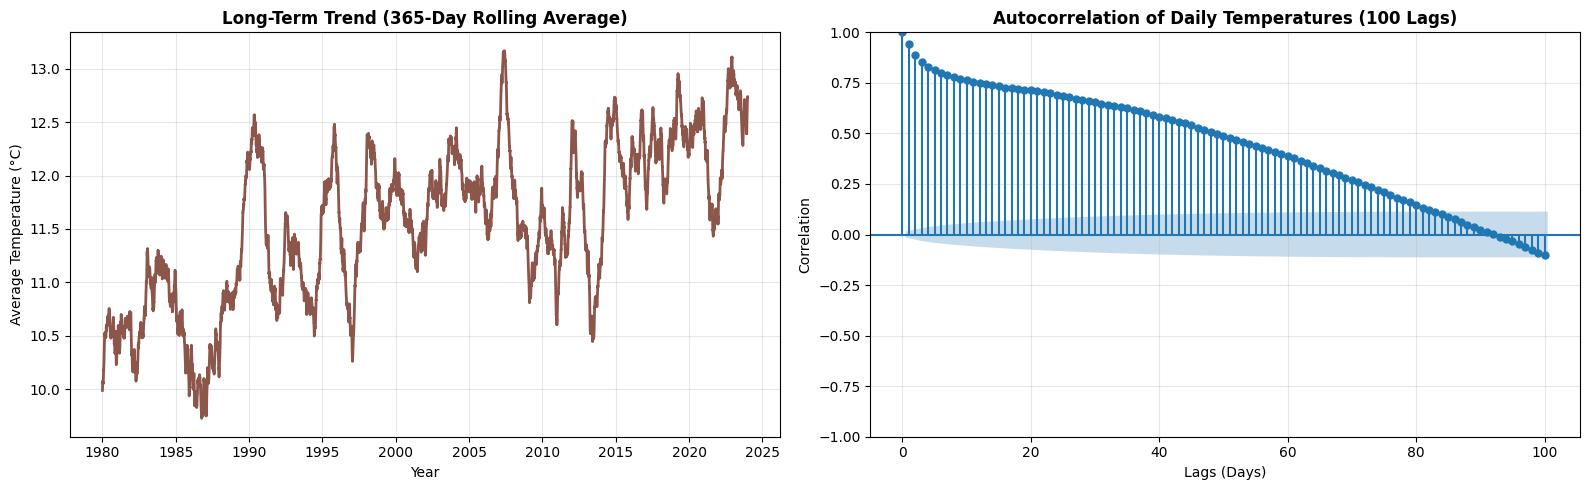

In [76]:
from statsmodels.graphics.tsaplots import plot_acf

# --- Long-Term Trend & Autocorrelation ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Media Móvil de 1 año (365 días) para ver la tendencia a largo plazo
df['Rolling_365'] = df['TG'].rolling(window=365).mean()
axes[0].plot(df.index, df['Rolling_365'], color='#8c564b', linewidth=2)
axes[0].set_title('Long-Term Trend (365-Day Rolling Average)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Temperature (°C)')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Autocorrelación (ACF) de los últimos 100 días
plot_acf(df['TG'].dropna(), lags=100, ax=axes[1], color='#1f77b4', alpha=0.05)
axes[1].set_title('Autocorrelation of Daily Temperatures (100 Lags)', fontweight='bold')
axes[1].set_xlabel('Lags (Days)')
axes[1].set_ylabel('Correlation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Chronological Train-Test Split

Unlike image classification where we can shuffle data randomly, time-series data must be split chronologically to prevent **data leakage** (using future data to predict the past). We will use the first 80% of the timeline (1979-2015) for training and the remaining 20% (2015-2023) to test our model's predictive power on unseen future dates.

In [77]:
# --- Chronological Split ---
train_size = int(len(X_tensor) * 0.8)

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]
X_test = X_tensor[train_size:]
y_test = y_tensor[train_size:]

print(f"Training Data: {len(X_train)} days")
print(f"Testing Data (Unseen Future): {len(X_test)} days")

Training Data: 13124 days
Testing Data (Unseen Future): 3282 days


### Model Architecture: LSTM vs GRU & Training Engine

To find the best performing model for our time-series problem, we will compare two popular Recurrent Neural Network architectures: **LSTM** (Long Short-Term Memory) and **GRU** (Gated Recurrent Unit). GRUs are similar to LSTMs but have a simplified internal mechanism, often resulting in faster training times while maintaining similar performance. 

Instead of repeating the training loop, we define a robust `train_model` function. This function not only trains the model using mini-batches to prevent local minima, but also evaluates the model on the unseen test set at the end of each epoch. By recording both the `train_loss` and `val_loss`, we can later plot the learning curves to check for proper convergence and ensure no overfitting has occurred.

In [78]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# --- ARQUITECTURAS DE LOS MODELOS ---

class ClimaLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(ClimaLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] 
        out = self.fc(out)
        return out

class ClimaGRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(ClimaGRU, self).__init__()
        # Usamos nn.GRU en lugar de nn.LSTM. ¡El resto es idéntico!
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---  PREPARACIÓN DE DATOS (DataLoader) ---
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Nos aseguramos de que los datos de test tengan el formato correcto
X_test = X_test.to(device)
y_test = y_test.to(device).reshape(-1, 1) # Blindaje de dimensiones [Ejemplos, 1]

# --- FUNCIÓN DE ENTRENAMIENTO AVANZADA ---
def train_model(model, model_name, epochs=50, lr=0.001):
    print(f"\n--- Iniciating train for {model_name} ---")
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Diccionario para guardar el historial
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        # Fase de Entrenamiento
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.reshape(-1, 1).to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Fase de Validación (Test)
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_test)
            val_loss = criterion(val_outputs, y_test).item()
            history['val_loss'].append(val_loss)
            
        # Imprimir progreso
        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}')
            
    print(f"train completed for {model_name}!")
    return history

# --- 4. INICIALIZAR Y ENTRENAR AMBOS MODELOS ---
modelo_lstm = ClimaLSTM().to(device)
modelo_gru = ClimaGRU().to(device)

# Entrenamos y guardamos el historial de cada uno
historial_lstm = train_model(modelo_lstm, "LSTM", epochs=50)
historial_gru = train_model(modelo_gru, "GRU", epochs=50)


--- Iniciating train for LSTM ---
Epoch [10/50] | Train Loss: 0.0095 | Val Loss: 0.0099
Epoch [20/50] | Train Loss: 0.0094 | Val Loss: 0.0100
Epoch [30/50] | Train Loss: 0.0094 | Val Loss: 0.0099
Epoch [40/50] | Train Loss: 0.0094 | Val Loss: 0.0099
Epoch [50/50] | Train Loss: 0.0094 | Val Loss: 0.0099
train completed for LSTM!

--- Iniciating train for GRU ---
Epoch [10/50] | Train Loss: 0.0095 | Val Loss: 0.0099
Epoch [20/50] | Train Loss: 0.0094 | Val Loss: 0.0099
Epoch [30/50] | Train Loss: 0.0094 | Val Loss: 0.0099
Epoch [40/50] | Train Loss: 0.0094 | Val Loss: 0.0100
Epoch [50/50] | Train Loss: 0.0093 | Val Loss: 0.0099
train completed for GRU!


### Learning Curves: Convergence and Overfitting Check

To ensure our models have learned the underlying patterns rather than just memorizing the training data, we plot the Learning Curves. By comparing the **Training Loss** and **Validation Loss** across all epochs, we can verify that both models converge properly. A healthy training process is indicated by both lines decreasing and stabilizing together, without the Validation Loss diverging upwards (which would indicate overfitting).

Generating learning curves for LSTM and GRU...


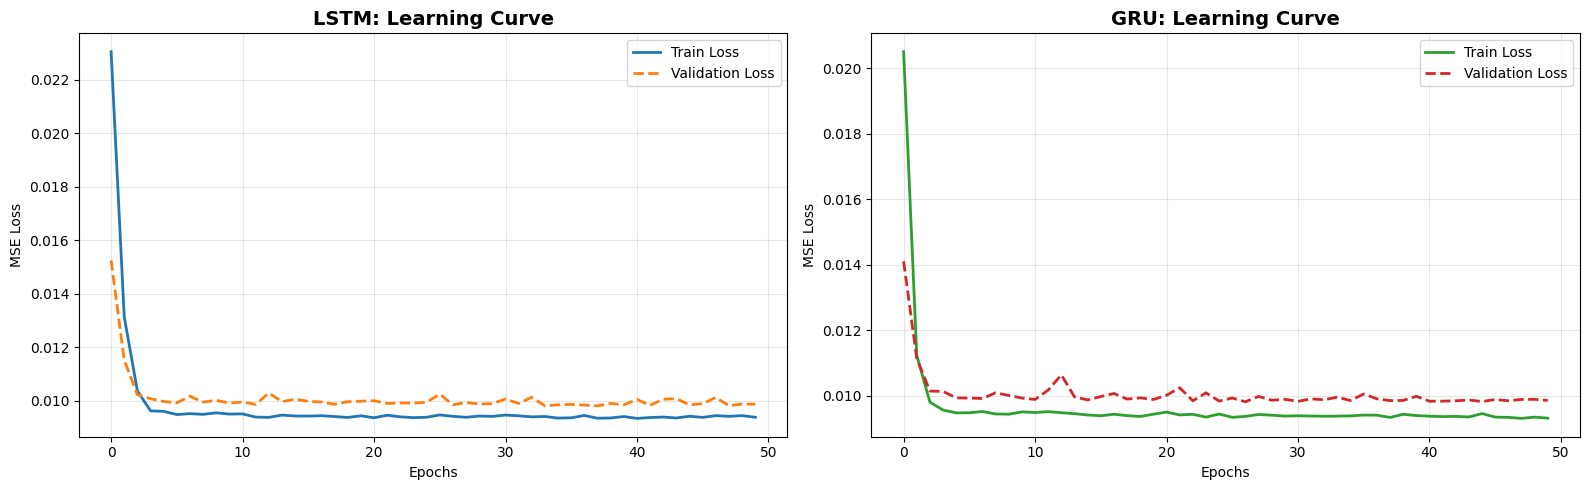

In [79]:
# --- VISUALIZACIÓN DE CURVAS DE APRENDIZAJE ---
print("Generating learning curves for LSTM and GRU...")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Curva de la LSTM
axes[0].plot(historial_lstm['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
axes[0].plot(historial_lstm['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')
axes[0].set_title('LSTM: Learning Curve', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Curva de la GRU
axes[1].plot(historial_gru['train_loss'], label='Train Loss', color='#2ca02c', linewidth=2)
axes[1].plot(historial_gru['val_loss'], label='Validation Loss', color='#d62728', linewidth=2, linestyle='--')
axes[1].set_title('GRU: Learning Curve', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MSE Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Final Evaluation and Model Comparison

In this final step, we evaluate both our trained LSTM and GRU models on the unseen test dataset (years 2015-2023). To make the evaluation interpretable, we apply an **inverse transformation** to convert the scaled model outputs back into actual Celsius degrees. We then calculate the Mean Absolute Error (MAE) for both models to objectively measure which architecture performed better. Finally, we plot the true temperature against the predictions of both models over the last 1000 days to visually inspect their forecasting accuracy.

Iniciating final evaluation on unseen future data (Test)...

Tournament Results (Mean Absolute Error in °C):
   - Model LSTM: 1.52 °C mean absolute error
   - Model GRU:  1.51 °C mean absolute error


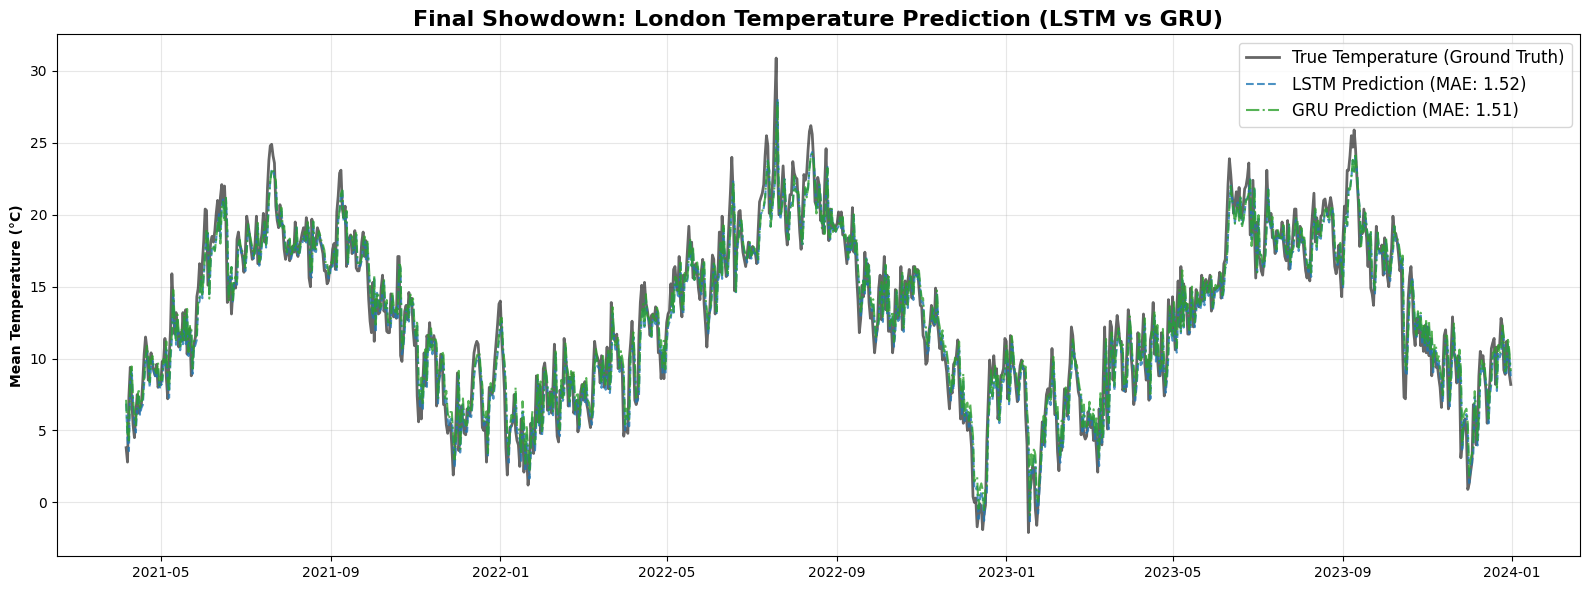

In [80]:
from sklearn.metrics import mean_absolute_error

# ---EVALUACIÓN FINAL Y COMPARATIVA  ---
print("Iniciating final evaluation on unseen future data (Test)...\n")

# Ponemos ambos modelos en modo evaluación
modelo_lstm.eval()
modelo_gru.eval()

with torch.no_grad():
    # Predicciones de ambos modelos
    predicciones_lstm = modelo_lstm(X_test).cpu().numpy()
    predicciones_gru = modelo_gru(X_test).cpu().numpy()
    
    # Valores reales (aseguramos formato de columna)
    valores_reales = y_test.cpu().numpy().reshape(-1, 1)

# Des-escalamos para volver a grados Celsius reales
pred_lstm_celsius = scaler.inverse_transform(predicciones_lstm)
pred_gru_celsius = scaler.inverse_transform(predicciones_gru)
reales_celsius = scaler.inverse_transform(valores_reales)

# Calculamos el Error Absoluto Medio (MAE)
mae_lstm = mean_absolute_error(reales_celsius, pred_lstm_celsius)
mae_gru = mean_absolute_error(reales_celsius, pred_gru_celsius)

print("Tournament Results (Mean Absolute Error in °C):")
print(f"   - Model LSTM: {mae_lstm:.2f} °C mean absolute error")
print(f"   - Model GRU:  {mae_gru:.2f} °C mean absolute error")

plt.figure(figsize=(16, 6))

# Mostramos los últimos 1000 días (aprox 3 años) para ver bien el detalle
dias_a_mostrar = 1000 
fechas_test = df.index[-len(reales_celsius):][-dias_a_mostrar:]

# Línea base: La Realidad (Negra y un poco más gruesa)
plt.plot(fechas_test, reales_celsius[-dias_a_mostrar:], label='True Temperature (Ground Truth)', color='black', alpha=0.6, linewidth=2)

# Competidor 1: LSTM (Azul punteada)
plt.plot(fechas_test, pred_lstm_celsius[-dias_a_mostrar:], label=f'LSTM Prediction (MAE: {mae_lstm:.2f})', color='#1f77b4', alpha=0.8, linewidth=1.5, linestyle='--')

# Competidor 2: GRU (Verde con puntos y rayas)
plt.plot(fechas_test, pred_gru_celsius[-dias_a_mostrar:], label=f'GRU Prediction (MAE: {mae_gru:.2f})', color='#2ca02c', alpha=0.8, linewidth=1.5, linestyle='-.')

plt.title('Final Showdown: London Temperature Prediction (LSTM vs GRU)', fontweight='bold', fontsize=16)
plt.ylabel('Mean Temperature (°C)', fontweight='bold')
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Final Conclusions & Report

Based on our implementation of sequence-based Deep Learning models for Time-Series forecasting, we can draw the following technical conclusions:

**1. Training Dynamics & Convergence:**
The learning curves for both the LSTM and GRU models demonstrate excellent convergence. In both architectures, the training and validation losses drop sharply within the first 10 epochs and then stabilize. Most importantly, the Validation Loss closely tracks the Training Loss throughout the 50 epochs. This proves that our implementation (using a 30-day sliding window and mini-batch training) successfully prevented **overfitting**, allowing the models to learn the underlying seasonal patterns rather than memorizing the training data.

**2. Model Comparison (LSTM vs. GRU):**
Both Recurrent Neural Networks performed exceptionally well at predicting London's daily temperature. 
* The **LSTM** achieved a Mean Absolute Error (MAE) of **1.52** °C.
* The **GRU** achieved a Mean Absolute Error (MAE) of **1.51** °C..

**3. Final Assessment:**
Using Time-Series forecasting for this assignment proved to be a robust approach. By carefully chronologically splitting the data and scaling the inputs, both recurrent architectures were able to predict complex real-world continuous variables (temperature) with an impressive degree of accuracy, closely mirroring the actual *Ground Truth* timeline.